In [2]:
from utils.config import RAW_CONFIG, RELEVANT_CONFIG, PROJECT_ROOT
from netCDF4 import Dataset as NETCDF4Dataset
from utils.datasettemporal import TemporalDataset
import os
from pathlib import Path

In [4]:
root = Path(PROJECT_ROOT)
filepath = root / "data/daily_small/small_daily_sample_1993-1993.nc"
dataset = TemporalDataset(filepath = filepath, normalize = False)

In [6]:
feature_map = dataset.feature_map
annotation_map = dataset.annotations_map
feature_map.shape, annotation_map.shape

((30, 6, 145, 157), (30, 1, 145, 157))

In [17]:
one_day_feature_map, one_day_annotation_map = feature_map[0:1], annotation_map[0:1]
one_day_feature_map.shape, one_day_annotation_map.shape

((1, 6, 145, 157), (1, 1, 145, 157))

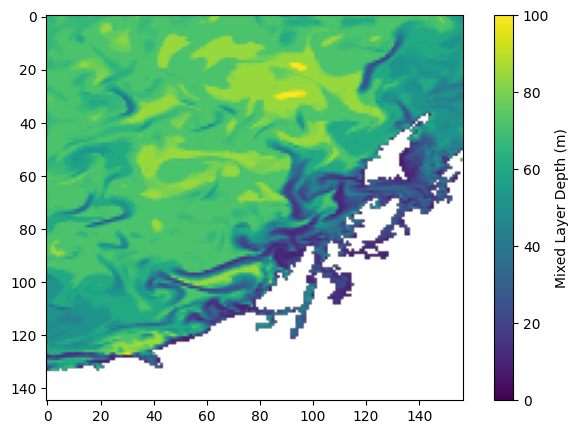

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(one_day_annotation_map[0, 0, :, :], cmap='viridis', vmin=0, vmax=100)
plt.colorbar(fraction=0.046, pad=0.04, label='Mixed Layer Depth (m)')


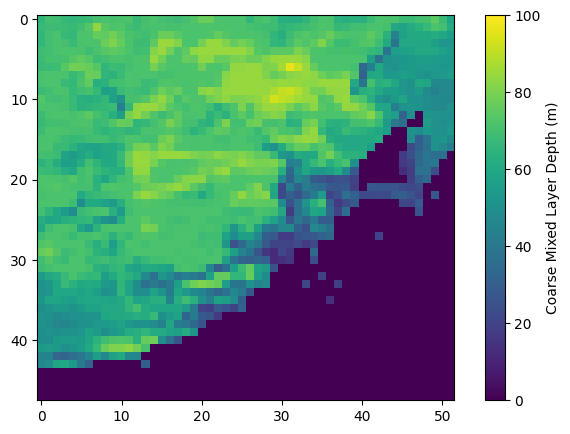

In [41]:
import torch.nn.functional as F
import torch

one_day_annotation_map_tensor = torch.tensor(one_day_annotation_map, dtype=torch.float32)
one_day_annotation_map_coarse = F.avg_pool2d(one_day_annotation_map_tensor, kernel_size=(3, 3), stride=(3, 3), padding=0)
one_day_annotation_map_coarse.shape

plt.figure(figsize=(10, 5))
plt.imshow(one_day_annotation_map_coarse[0, 0, :, :], cmap='viridis', vmin=0, vmax=100)
plt.colorbar(fraction=0.046, pad=0.04, label='Coarse Mixed Layer Depth (m)')

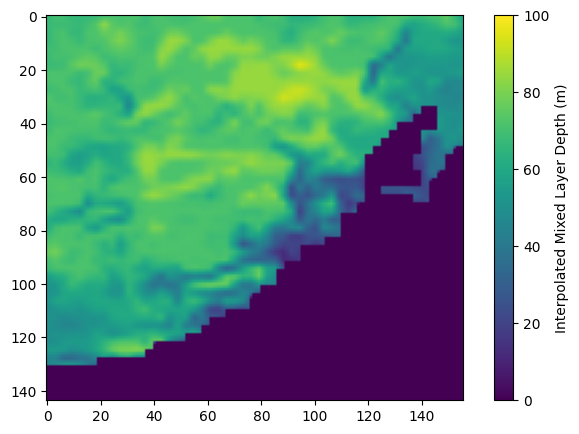

torch.Size([1, 1, 144, 156])


In [42]:
one_day_annotation_map_coarse_interpolated = F.interpolate(one_day_annotation_map_coarse, scale_factor=3, mode='bilinear', align_corners=True)
plt.figure(figsize=(10, 5))
plt.imshow(one_day_annotation_map_coarse_interpolated[0, 0, :, :], cmap='viridis', vmin=0, vmax=100)
plt.colorbar(fraction=0.046, pad=0.04, label='Interpolated Mixed Layer Depth (m)')
plt.show()
print(one_day_annotation_map_coarse_interpolated.shape)